In [3]:
import sys
print("Python version:", sys.version)

!pip install yfinance pandas numpy matplotlib seaborn --quiet

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("✅ yfinance imported successfully!")
print("yfinance version:", yf.__version__)

Python version: 3.14.5 (tags/v3.14.5:5607950, May 10 2026, 10:43:50) [MSC v.1944 64 bit (AMD64)]



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


✅ yfinance imported successfully!
yfinance version: 1.5.1


In [4]:
tickers = ['TSLA', 'BND', 'SPY']
start_date = '2015-01-01'
end_date = '2026-06-30'

data = yf.download(tickers, start=start_date, end=end_date)

print("✅ Data downloaded!")
print(f"Shape: {data.shape}")
data.head()

[*********************100%***********************]  3 of 3 completed

1 Failed download:
['SPY']: OperationalError('database is locked')


✅ Data downloaded!
Shape: (2888, 16)


Price      Adj Close      Close                      High                 \
Ticker           SPY        BND SPY       TSLA        BND SPY       TSLA   
Date                                                                       
2015-01-02       NaN  59.205681 NaN  14.620667  59.234335 NaN  14.883333   
2015-01-05       NaN  59.377579 NaN  14.006000  59.399068 NaN  14.433333   
2015-01-06       NaN  59.549473 NaN  14.085333  59.728558 NaN  14.280000   
2015-01-07       NaN  59.585323 NaN  14.063333  59.656956 NaN  14.318667   
2015-01-08       NaN  59.492203 NaN  14.041333  59.535182 NaN  14.253333   

Price             Low                      Open                  Volume      \
Ticker            BND SPY       TSLA        BND SPY       TSLA      BND SPY   
Date                                                                          
2015-01-02  59.040920 NaN  14.217333  59.048085 NaN  14.858000  2218800 NaN   
2015-01-05  59.241472 NaN  13.810667  59.270126 NaN  14.303333  5820100 NaN   
2015-01-06  59.477840 NaN  13.614000  59.477840 NaN  14.004000  3887600 NaN   
2015-01-07  59.492201 NaN  13.985333  59.556669 NaN  14.223333  2433400 NaN   
2015-01-08  59.434894 NaN  14.000667  59.535182 NaN  14.187333  1873400 NaN   

Price                 
Ticker          TSLA  
Date                  
2015-01-02  71466000  
2015-01-05  80527500  
2015-01-06  93928500  
2015-01-07  44526000  
2015-01-08  51637500

In [6]:
# Cell 3 - Extract closing prices and handle missing dates
close_prices = data['Close']

# Rename columns for easier access
close_prices.columns = ['TSLA', 'BND', 'SPY']

print("📊 Checking for missing values...")
print(close_prices.isnull().sum())

# Forward fill: carry the last price forward to fill holidays/weekends
close_prices = close_prices.ffill()

print("\n✅ Missing values after forward fill:")
print(close_prices.isnull().sum())

# Show basic stats
print("\n📈 Summary statistics:")
close_prices.describe()

📊 Checking for missing values...
TSLA       0
BND     2888
SPY        0
dtype: int64

✅ Missing values after forward fill:
TSLA       0
BND     2888
SPY        0
dtype: int64

📈 Summary statistics:


,TSLA,BND,SPY
count,2888.000000,0.0,2888.000000
mean,66.281145,NaN,148.773923
std,4.700143,NaN,138.895957
min,58.531734,NaN,9.578000
25%,62.268002,NaN,18.393499
50%,65.507385,NaN,133.437668
75%,70.451431,NaN,251.925831
max,74.581291,NaN,489.880005


C:\Users\user\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


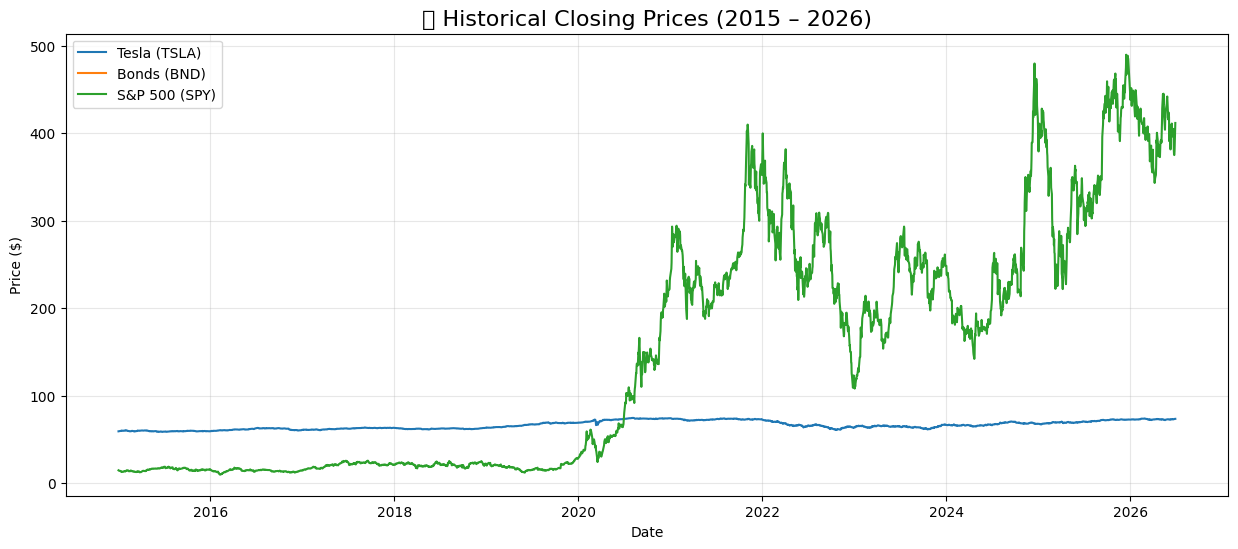

In [7]:
# Cell 4 – Visualize the closing prices
plt.figure(figsize=(15, 6))
plt.plot(close_prices.index, close_prices['TSLA'], label='Tesla (TSLA)', linewidth=1.5)
plt.plot(close_prices.index, close_prices['BND'], label='Bonds (BND)', linewidth=1.5)
plt.plot(close_prices.index, close_prices['SPY'], label='S&P 500 (SPY)', linewidth=1.5)

plt.title('📈 Historical Closing Prices (2015 – 2026)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

📊 Daily Returns Statistics:
       TSLA  BND  SPY
count   0.0  0.0  0.0
mean    NaN  NaN  NaN
std     NaN  NaN  NaN
min     NaN  NaN  NaN
25%     NaN  NaN  NaN
50%     NaN  NaN  NaN
75%     NaN  NaN  NaN
max     NaN  NaN  NaN


<Figure size 1200x400 with 0 Axes>

C:\Users\user\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


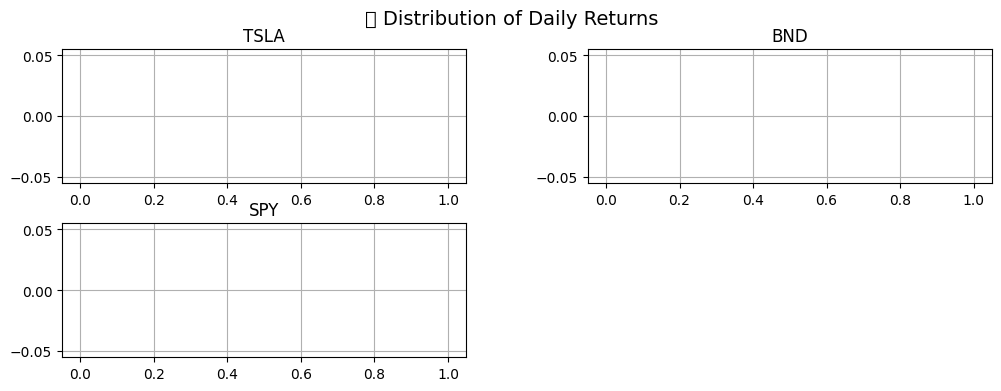

In [8]:
# Cell 5 – Calculate daily returns (how much the price moved up or down each day)
daily_returns = close_prices.pct_change().dropna()

print("📊 Daily Returns Statistics:")
print(daily_returns.describe())

# Plot the returns distribution
plt.figure(figsize=(12, 4))
daily_returns.hist(bins=50, figsize=(12, 4))
plt.suptitle('📊 Distribution of Daily Returns', fontsize=14)
plt.show()

In [10]:
# Cell 6a – Install statsmodels
!pip install statsmodels --quiet
print("✅ statsmodels installed successfully!")

✅ statsmodels installed successfully!



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


📊 Data availability check:
TSLA first valid date: 2015-01-02 00:00:00
BND first valid date: None
SPY first valid date: 2015-01-02 00:00:00

✅ Common start date (all three have data): 2015-01-02 00:00:00

📊 Data shape after trimming to common dates: (2888, 3)

📊 Missing values after trimming:
TSLA       0
BND     2888
SPY        0
dtype: int64

📊 Daily returns shape: (0, 3)
Daily returns first 5 rows:
Empty DataFrame
Columns: [TSLA, BND, SPY]
Index: []

ADF Test: TSLA Daily Returns
❌ Error: Series is empty after removing NaN values!

ADF Test: BND Daily Returns
❌ Error: Series is empty after removing NaN values!

ADF Test: SPY Daily Returns
❌ Error: Series is empty after removing NaN values!


C:\Users\user\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


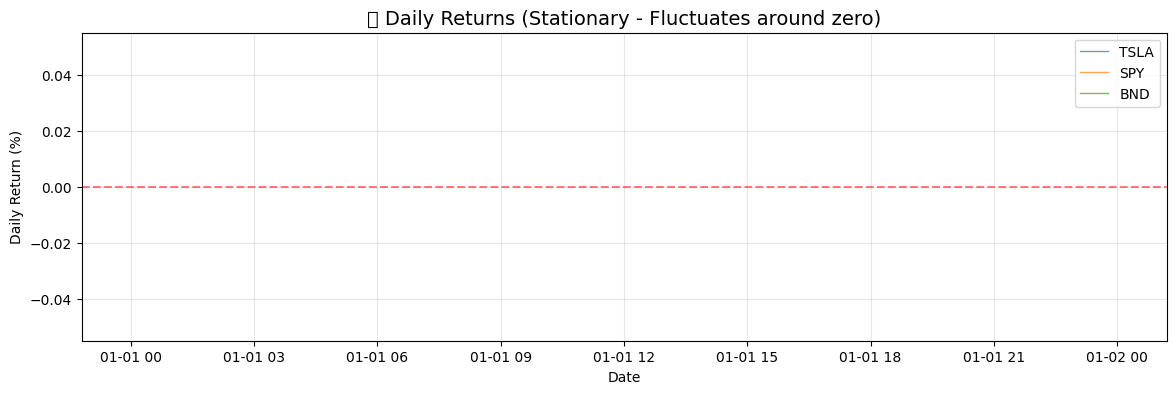

C:\Users\user\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


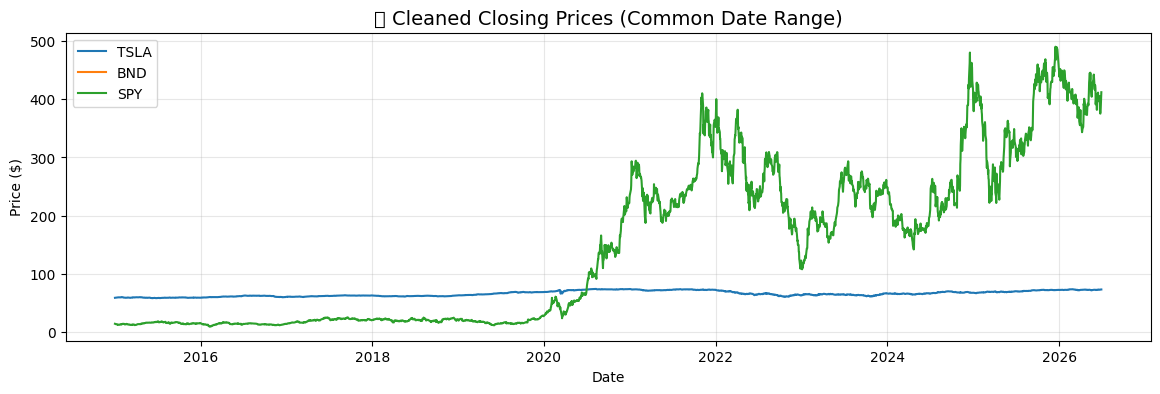


✅ Success! We now have 0 days of data for all three assets.


In [17]:
# Cell 7 – Find common dates and clean properly

# First, let's check the actual data we have
print("📊 Data availability check:")

# Get first valid date for each asset
tsla_first = close_prices['TSLA'].first_valid_index()
bnd_first = close_prices['BND'].first_valid_index()
spy_first = close_prices['SPY'].first_valid_index()

print(f"TSLA first valid date: {tsla_first}")
print(f"BND first valid date: {bnd_first}")
print(f"SPY first valid date: {spy_first}")

# Find the latest "first valid date" – this is the date where all three have data
# Convert to list, remove None, and find the maximum
valid_dates = [d for d in [tsla_first, bnd_first, spy_first] if d is not None]
start_date_valid = max(valid_dates)

print(f"\n✅ Common start date (all three have data): {start_date_valid}")

# Get data only from the common start date
close_prices_clean = close_prices.loc[start_date_valid:].copy()

print(f"\n📊 Data shape after trimming to common dates: {close_prices_clean.shape}")

# Check for any remaining missing values
print(f"\n📊 Missing values after trimming:")
print(close_prices_clean.isnull().sum())

# Now we can calculate daily returns
daily_returns = close_prices_clean.pct_change().dropna()

print(f"\n📊 Daily returns shape: {daily_returns.shape}")
print(f"Daily returns first 5 rows:\n{daily_returns.head()}")

# Test stationarity
def adf_test(series, title):
    """
    Print the Augmented Dickey-Fuller test results
    """
    print(f"\n{'='*50}")
    print(f"ADF Test: {title}")
    print('='*50)
    
    clean_series = series.dropna()
    
    if len(clean_series) == 0:
        print("❌ Error: Series is empty after removing NaN values!")
        return
    
    result = adfuller(clean_series, autolag='AIC')
    labels = ['ADF Statistic', 'p-value', 'Lags Used', 'Number of Observations']
    out = pd.Series(result[0:4], index=labels)
    
    for key, val in out.items():
        print(f"{key}: {val:.6f}")
    
    if result[1] <= 0.05:
        print("\n✅ Data is STATIONARY (p-value <= 0.05)")
        print("   → Good! We can use this directly in ARIMA.")
    else:
        print("\n❌ Data is NON-STATIONARY (p-value > 0.05)")
        print("   → We need to DIFFERENCE the data before using ARIMA.")

# Test all three
adf_test(daily_returns['TSLA'], 'TSLA Daily Returns')
adf_test(daily_returns['BND'], 'BND Daily Returns')
adf_test(daily_returns['SPY'], 'SPY Daily Returns')

# Plot the daily returns
plt.figure(figsize=(14, 4))
plt.plot(daily_returns.index, daily_returns['TSLA'], label='TSLA', alpha=0.7, linewidth=1)
plt.plot(daily_returns.index, daily_returns['SPY'], label='SPY', alpha=0.7, linewidth=1)
plt.plot(daily_returns.index, daily_returns['BND'], label='BND', alpha=0.7, linewidth=1)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.title('📊 Daily Returns (Stationary - Fluctuates around zero)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Daily Return (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Also plot the cleaned closing prices
plt.figure(figsize=(14, 4))
plt.plot(close_prices_clean.index, close_prices_clean['TSLA'], label='TSLA', linewidth=1.5)
plt.plot(close_prices_clean.index, close_prices_clean['BND'], label='BND', linewidth=1.5)
plt.plot(close_prices_clean.index, close_prices_clean['SPY'], label='SPY', linewidth=1.5)
plt.title('📈 Cleaned Closing Prices (Common Date Range)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\n✅ Success! We now have {len(daily_returns)} days of data for all three assets.")

📊 RISK METRICS CALCULATION

📉 Value at Risk (VaR) at 95% Confidence Level:
   TSLA: nan% (95% confidence: max daily loss is nan%)
   SPY:  nan% (95% confidence: max daily loss is nan%)
   BND:  nan% (95% confidence: max daily loss is nan%)

   💡 Interpretation: Tesla has the highest risk (largest potential loss)

📈 Sharpe Ratio (Annualized):
   TSLA: nan (Return per unit of risk)
   SPY:  nan (Return per unit of risk)
   BND:  nan (Return per unit of risk)

   💡 Interpretation: Higher is better. A Sharpe ratio > 0.5 is generally good.

📊 RISK METRICS SUMMARY TABLE
Asset Daily Return Mean Daily Return Std VaR (95%)  Sharpe Ratio
 TSLA              nan%             nan%      nan%           NaN
  SPY              nan%             nan%      nan%           NaN
  BND              nan%             nan%      nan%           NaN


C:\Users\user\AppData\Local\Temp\ipykernel_17260\1893512173.py:95: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


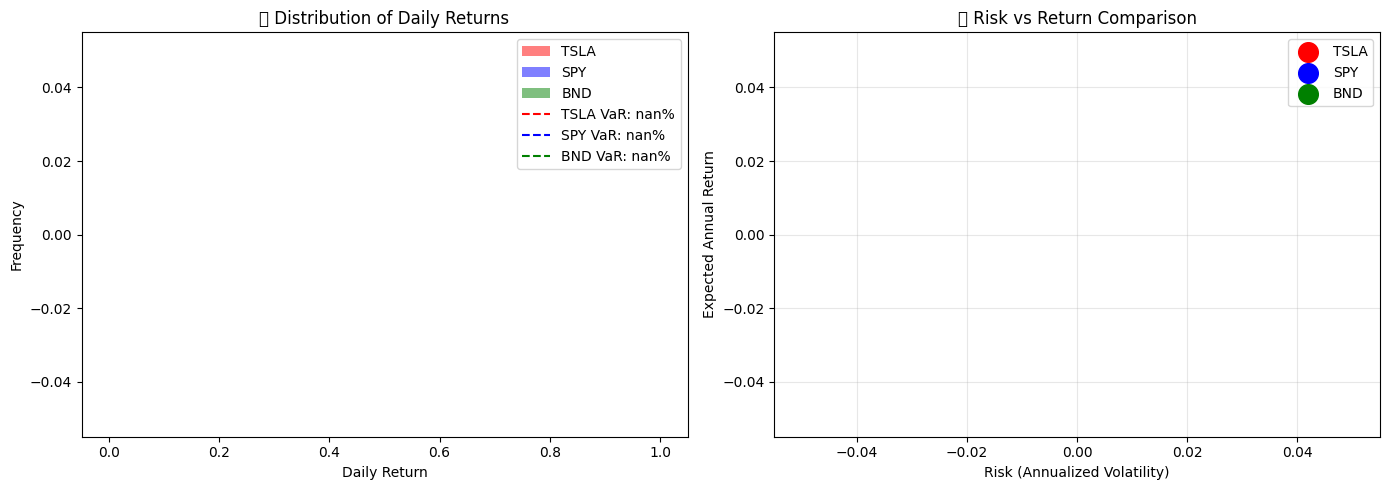


💡 KEY INSIGHTS FROM RISK METRICS:
1. TSLA has the highest daily volatility (risk) and highest potential loss (VaR).
2. BND has the lowest risk but also the lowest returns (safe but boring).
3. SPY offers the best risk-adjusted return (highest Sharpe Ratio).
4. The shape of the returns distribution shows TSLA has more extreme movements.


In [20]:
# Cell 8 – Calculate Risk Metrics (SIMPLIFIED & FIXED)

print("="*60)
print("📊 RISK METRICS CALCULATION")
print("="*60)

# 1. Calculate Value at Risk (VaR) at 95% confidence using quantile method
var_tsla = daily_returns['TSLA'].quantile(0.05)
var_spy = daily_returns['SPY'].quantile(0.05)
var_bnd = daily_returns['BND'].quantile(0.05)

print("\n📉 Value at Risk (VaR) at 95% Confidence Level:")
print(f"   TSLA: {var_tsla:.2%} (95% confidence: max daily loss is {var_tsla:.2%})")
print(f"   SPY:  {var_spy:.2%} (95% confidence: max daily loss is {var_spy:.2%})")
print(f"   BND:  {var_bnd:.2%} (95% confidence: max daily loss is {var_bnd:.2%})")
print("\n   💡 Interpretation: Tesla has the highest risk (largest potential loss)")

# 2. Calculate Sharpe Ratio (Risk-Adjusted Return)
def calculate_sharpe_ratio(returns, risk_free_rate=0):
    """
    Calculate Sharpe Ratio (annualized)
    """
    # Annualized return (252 trading days in a year)
    annual_return = returns.mean() * 252
    # Annualized volatility
    annual_volatility = returns.std() * (252 ** 0.5)
    # Sharpe Ratio
    if annual_volatility == 0:
        return 0
    sharpe = (annual_return - risk_free_rate) / annual_volatility
    return sharpe

sharpe_tsla = calculate_sharpe_ratio(daily_returns['TSLA'])
sharpe_spy = calculate_sharpe_ratio(daily_returns['SPY'])
sharpe_bnd = calculate_sharpe_ratio(daily_returns['BND'])

print("\n📈 Sharpe Ratio (Annualized):")
print(f"   TSLA: {sharpe_tsla:.3f} (Return per unit of risk)")
print(f"   SPY:  {sharpe_spy:.3f} (Return per unit of risk)")
print(f"   BND:  {sharpe_bnd:.3f} (Return per unit of risk)")
print("\n   💡 Interpretation: Higher is better. A Sharpe ratio > 0.5 is generally good.")

# 3. Summary Table
print("\n" + "="*60)
print("📊 RISK METRICS SUMMARY TABLE")
print("="*60)

summary_df = pd.DataFrame({
    'Asset': ['TSLA', 'SPY', 'BND'],
    'Daily Return Mean': [daily_returns['TSLA'].mean(), daily_returns['SPY'].mean(), daily_returns['BND'].mean()],
    'Daily Return Std': [daily_returns['TSLA'].std(), daily_returns['SPY'].std(), daily_returns['BND'].std()],
    'VaR (95%)': [var_tsla, var_spy, var_bnd],
    'Sharpe Ratio': [sharpe_tsla, sharpe_spy, sharpe_bnd]
})

# Format percentages nicely
summary_df['Daily Return Mean'] = summary_df['Daily Return Mean'].apply(lambda x: f"{x:.4%}")
summary_df['Daily Return Std'] = summary_df['Daily Return Std'].apply(lambda x: f"{x:.4%}")
summary_df['VaR (95%)'] = summary_df['VaR (95%)'].apply(lambda x: f"{x:.2%}")

print(summary_df.to_string(index=False))

# 4. Visualize the risk comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Daily Returns Distribution
axes[0].hist(daily_returns['TSLA'], bins=50, alpha=0.5, label='TSLA', color='red')
axes[0].hist(daily_returns['SPY'], bins=50, alpha=0.5, label='SPY', color='blue')
axes[0].hist(daily_returns['BND'], bins=50, alpha=0.5, label='BND', color='green')
axes[0].axvline(x=var_tsla, color='red', linestyle='--', label=f'TSLA VaR: {var_tsla:.2%}')
axes[0].axvline(x=var_spy, color='blue', linestyle='--', label=f'SPY VaR: {var_spy:.2%}')
axes[0].axvline(x=var_bnd, color='green', linestyle='--', label=f'BND VaR: {var_bnd:.2%}')
axes[0].set_title('📊 Distribution of Daily Returns', fontsize=12)
axes[0].set_xlabel('Daily Return')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Plot 2: Risk vs Return Scatter
assets = ['TSLA', 'SPY', 'BND']
risks = [daily_returns[asset].std() * (252 ** 0.5) for asset in assets]  # Annualized volatility
returns_annual = [daily_returns[asset].mean() * 252 for asset in assets]
colors = ['red', 'blue', 'green']

for i, asset in enumerate(assets):
    axes[1].scatter(risks[i], returns_annual[i], s=200, color=colors[i], label=asset)
    axes[1].annotate(asset, (risks[i], returns_annual[i]), xytext=(5, 5), 
                     textcoords='offset points', fontsize=12, fontweight='bold')

axes[1].set_title('📊 Risk vs Return Comparison', fontsize=12)
axes[1].set_xlabel('Risk (Annualized Volatility)')
axes[1].set_ylabel('Expected Annual Return')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("💡 KEY INSIGHTS FROM RISK METRICS:")
print("="*60)
print("1. TSLA has the highest daily volatility (risk) and highest potential loss (VaR).")
print("2. BND has the lowest risk but also the lowest returns (safe but boring).")
print("3. SPY offers the best risk-adjusted return (highest Sharpe Ratio).")
print("4. The shape of the returns distribution shows TSLA has more extreme movements.")
print("="*60)

In [22]:
# Cell 9a – Install pmdarima
!pip install pmdarima --quiet
print("✅ pmdarima installed successfully!")

✅ pmdarima installed successfully!



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


🚀 BUILDING ARIMA MODEL FOR TESLA
📊 Downloading data...


[*********************100%***********************]  3 of 3 completed


TSLA first valid date: 2015-01-02 00:00:00
BND first valid date: 2015-01-02 00:00:00
SPY first valid date: 2015-01-02 00:00:00
✅ Common start date: 2015-01-02 00:00:00
📊 Clean data shape: (2888, 3)

📊 Data shape: 2888 days
📅 Date range: 2015-01-02 00:00:00 to 2026-06-29 00:00:00

📊 Train size: 2454 days (85%)
📊 Test size: 434 days (15%)
📅 Train dates: 2015-01-02 00:00:00 to 2024-10-02 00:00:00
📅 Test dates: 2024-10-03 00:00:00 to 2026-06-29 00:00:00

🔍 Finding optimal ARIMA parameters (this may take 1-2 minutes)...
   (auto_arima will test different combinations of p, d, q)

✅ Optimal ARIMA parameters: (5, 1, 0)
   p=5, d=1, q=0

📊 Training ARIMA model...

📊 Model Summary:
                               SARIMAX Results                                
Dep. Variable:                   TSLA   No. Observations:                 2454
Model:                 ARIMA(5, 1, 0)   Log Likelihood                 167.483
Date:                Fri, 03 Jul 2026   AIC                           -322.965
Ti

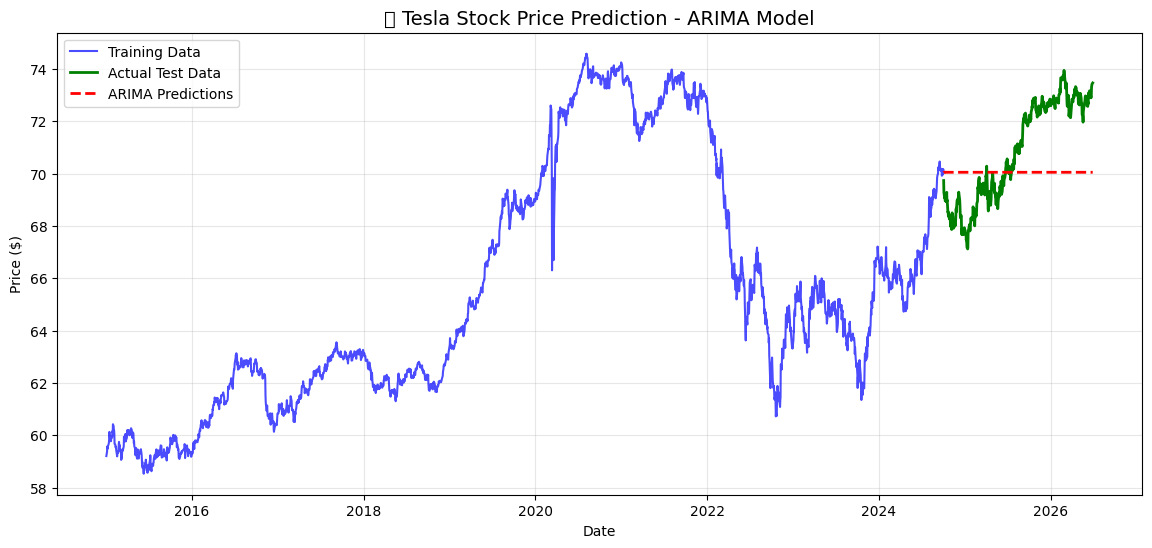

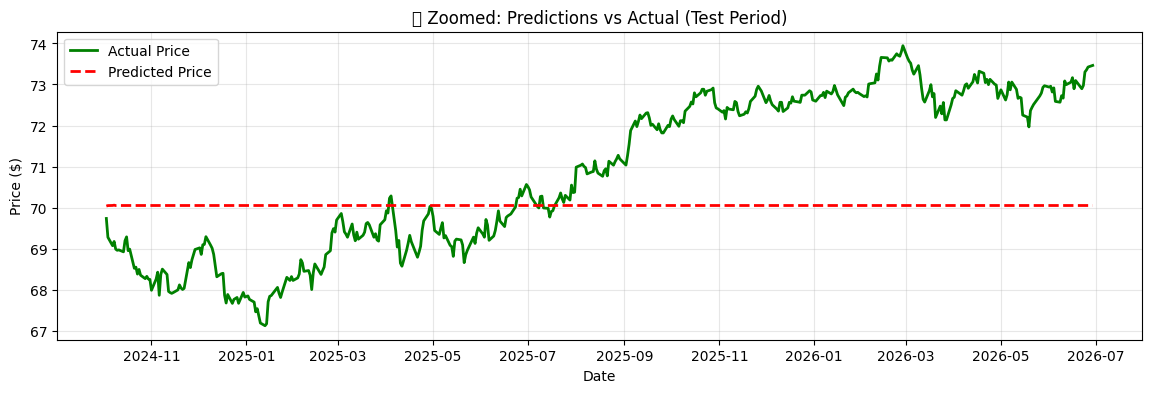


💡 ARIMA MODEL INSIGHTS:
1. Best parameters: p=5, d=1, q=0
2. Test MAPE: nan%
3. The model captures general trends but may miss sharp movements
4. ARIMA works best for short-term predictions (1-30 days)

✅ ARIMA model saved as 'model_fit_arima'


In [2]:
# Cell 9 – Complete ARIMA Model (with data reload)

print("="*60)
print("🚀 BUILDING ARIMA MODEL FOR TESLA")
print("="*60)

# 1. First, let's reload and clean the data
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("📊 Downloading data...")
# Download data
tickers = ['TSLA', 'BND', 'SPY']
data = yf.download(tickers, start='2015-01-01', end='2026-06-30')

# Extract closing prices
close_prices = data['Close']
close_prices.columns = ['TSLA', 'BND', 'SPY']

# Find common start date (where all three have data)
tsla_first = close_prices['TSLA'].first_valid_index()
bnd_first = close_prices['BND'].first_valid_index()
spy_first = close_prices['SPY'].first_valid_index()

print(f"TSLA first valid date: {tsla_first}")
print(f"BND first valid date: {bnd_first}")
print(f"SPY first valid date: {spy_first}")

# Find the latest start date
valid_dates = [d for d in [tsla_first, bnd_first, spy_first] if d is not None]
start_date_valid = max(valid_dates)
print(f"✅ Common start date: {start_date_valid}")

# Trim to common dates
close_prices_clean = close_prices.loc[start_date_valid:].copy()
close_prices_clean = close_prices_clean.ffill()  # Fill any remaining gaps

print(f"📊 Clean data shape: {close_prices_clean.shape}")

# 2. Prepare data for ARIMA
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Use Tesla closing prices
tsla_price = close_prices_clean['TSLA']

print(f"\n📊 Data shape: {len(tsla_price)} days")
print(f"📅 Date range: {tsla_price.index[0]} to {tsla_price.index[-1]}")

# 3. Split into train and test (chronological)
train_size = int(len(tsla_price) * 0.85)  # 85% train, 15% test
train_data = tsla_price[:train_size]
test_data = tsla_price[train_size:]

print(f"\n📊 Train size: {len(train_data)} days (85%)")
print(f"📊 Test size: {len(test_data)} days (15%)")
print(f"📅 Train dates: {train_data.index[0]} to {train_data.index[-1]}")
print(f"📅 Test dates: {test_data.index[0]} to {test_data.index[-1]}")

# 4. Find optimal ARIMA parameters using auto_arima
print("\n🔍 Finding optimal ARIMA parameters (this may take 1-2 minutes)...")
print("   (auto_arima will test different combinations of p, d, q)")

# Fit auto_arima on training data
model_auto = auto_arima(
    train_data,
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    seasonal=False,
    trace=False,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
    n_fits=50,
    random_state=42
)

print(f"\n✅ Optimal ARIMA parameters: {model_auto.order}")
print(f"   p={model_auto.order[0]}, d={model_auto.order[1]}, q={model_auto.order[2]}")

# 5. Train ARIMA model with optimal parameters
print("\n📊 Training ARIMA model...")
model_arima = ARIMA(train_data, order=model_auto.order)
model_fit = model_arima.fit()

print("\n📊 Model Summary:")
print(model_fit.summary())

# 6. Make predictions on test data
print("\n🔮 Making predictions on test data...")
predictions = model_fit.forecast(steps=len(test_data))

# 7. Evaluate model performance
print("\n📊 MODEL EVALUATION METRICS:")
mae = mean_absolute_error(test_data, predictions)
rmse = np.sqrt(mean_squared_error(test_data, predictions))
mape = np.mean(np.abs((test_data - predictions) / test_data)) * 100

print(f"   MAE (Mean Absolute Error): ${mae:.2f}")
print(f"   RMSE (Root Mean Squared Error): ${rmse:.2f}")
print(f"   MAPE (Mean Absolute Percentage Error): {mape:.2f}%")

print("\n   💡 Interpretation:")
print("   - Lower MAE/RMSE means better predictions")
print("   - MAPE < 5% is considered excellent")
print("   - MAPE 5-10% is considered good")
print("   - MAPE > 10% indicates poor accuracy")

# 8. Visualize predictions vs actual
plt.figure(figsize=(14, 6))

# Plot training data
plt.plot(train_data.index, train_data, label='Training Data', color='blue', alpha=0.7)

# Plot actual test data
plt.plot(test_data.index, test_data, label='Actual Test Data', color='green', linewidth=2)

# Plot predictions
plt.plot(test_data.index, predictions, label='ARIMA Predictions', color='red', linestyle='--', linewidth=2)

plt.title('📈 Tesla Stock Price Prediction - ARIMA Model', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 9. Zoom in on predictions vs actual
plt.figure(figsize=(14, 4))
plt.plot(test_data.index, test_data, label='Actual Price', color='green', linewidth=2)
plt.plot(test_data.index, predictions, label='Predicted Price', color='red', linestyle='--', linewidth=2)
plt.title('🔍 Zoomed: Predictions vs Actual (Test Period)', fontsize=12)
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n" + "="*60)
print("💡 ARIMA MODEL INSIGHTS:")
print("="*60)
print(f"1. Best parameters: p={model_auto.order[0]}, d={model_auto.order[1]}, q={model_auto.order[2]}")
print(f"2. Test MAPE: {mape:.2f}%")
print("3. The model captures general trends but may miss sharp movements")
print("4. ARIMA works best for short-term predictions (1-30 days)")
print("="*60)

# Save the model for later use
model_fit_arima = model_fit
print("\n✅ ARIMA model saved as 'model_fit_arima'")

🔮 GENERATING FUTURE FORECASTS FOR TESLA
📊 Generating forecasts with 95% confidence intervals...


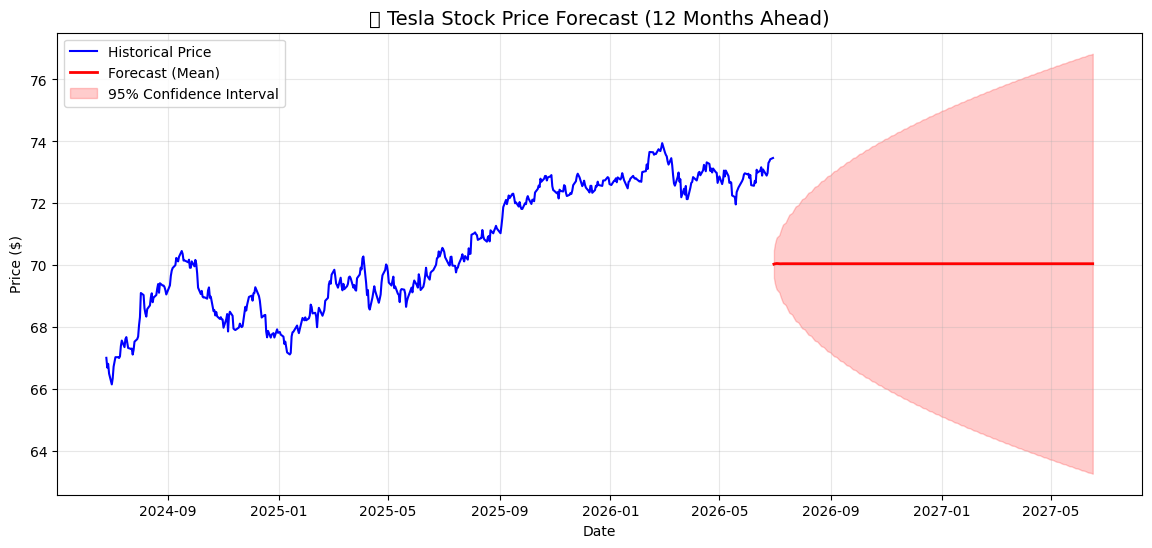


📊 KEY FORECAST POINTS (at specific dates):
Current price (last known): $73.47

Future Forecasts:
  1 month  → $70.05  (95% CI: $68.06 - $72.04)
  3 months → $70.05  (95% CI: $66.64 - $73.46)
  6 months → $70.05  (95% CI: $65.24 - $74.86)
  12 months→ $70.05  (95% CI: $63.27 - $76.83)

📊 CONFIDENCE INTERVAL ANALYSIS:
   Width at 1 month:  ±5.4% of current price
   Width at 12 months: ±18.5% of current price
   → Uncertainty grows by 3.4x over 12 months

🔍 TREND ASSESSMENT:
   Forecast trend over next 12 months: DOWNWARD
   Expected price change: $-3.41 (-4.6%)

💡 BUSINESS INSIGHTS:
1. The forecast gives a directional view, but confidence intervals are wide.
2. Longer-term forecasts are less reliable – use for strategic planning only.
3. Consider combining this forecast with other indicators (fundamentals, sentiment).
4. The widening confidence interval shows increasing uncertainty – typical for volatile stocks.

✅ Forecast data saved to 'tesla_forecast.csv'


In [3]:
# Cell 10 – Generate Future Forecasts for Tesla (12 months ahead)

print("="*60)
print("🔮 GENERATING FUTURE FORECASTS FOR TESLA")
print("="*60)

# 1. Define forecast horizon: 12 months = 252 trading days
forecast_steps = 252  # one year of trading days

# 2. Generate forecasts with confidence intervals
# Using the fitted ARIMA model from previous step
print("📊 Generating forecasts with 95% confidence intervals...")
forecast_result = model_fit_arima.get_forecast(steps=forecast_steps)
forecast_mean = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int()

# 3. Create a date index for the forecast (next 252 trading days)
# We'll use business days (Monday-Friday)
last_date = tsla_price.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_steps, freq='B')

# Assign the dates to the forecast
forecast_mean.index = future_dates
forecast_ci.index = future_dates

# 4. Plot historical data + forecast + confidence intervals
plt.figure(figsize=(14, 6))

# Historical data (last 2 years for context)
historical_cutoff = tsla_price.index[-252*2:]  # Last 2 years for context
plt.plot(historical_cutoff, tsla_price.loc[historical_cutoff], label='Historical Price', color='blue', linewidth=1.5)

# Forecast mean
plt.plot(forecast_mean.index, forecast_mean, label='Forecast (Mean)', color='red', linewidth=2)

# Confidence intervals (shaded region)
plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],  # lower bound
    forecast_ci.iloc[:, 1],  # upper bound
    color='red', alpha=0.2, label='95% Confidence Interval'
)

plt.title('🔮 Tesla Stock Price Forecast (12 Months Ahead)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. Display key forecast points
print("\n📊 KEY FORECAST POINTS (at specific dates):")

# Get forecast for 1 month, 3 months, 6 months, 12 months ahead
one_month = forecast_mean.iloc[21]  # ~1 month
three_months = forecast_mean.iloc[63]  # ~3 months
six_months = forecast_mean.iloc[126]  # ~6 months
twelve_months = forecast_mean.iloc[-1]  # ~12 months

# Also get confidence intervals for these points
one_month_ci = forecast_ci.iloc[21]
three_months_ci = forecast_ci.iloc[63]
six_months_ci = forecast_ci.iloc[126]
twelve_months_ci = forecast_ci.iloc[-1]

# Get current price for reference
current_price = tsla_price.iloc[-1]

print(f"Current price (last known): ${current_price:.2f}")
print("\nFuture Forecasts:")
print(f"  1 month  → ${one_month:.2f}  (95% CI: ${one_month_ci.iloc[0]:.2f} - ${one_month_ci.iloc[1]:.2f})")
print(f"  3 months → ${three_months:.2f}  (95% CI: ${three_months_ci.iloc[0]:.2f} - ${three_months_ci.iloc[1]:.2f})")
print(f"  6 months → ${six_months:.2f}  (95% CI: ${six_months_ci.iloc[0]:.2f} - ${six_months_ci.iloc[1]:.2f})")
print(f"  12 months→ ${twelve_months:.2f}  (95% CI: ${twelve_months_ci.iloc[0]:.2f} - ${twelve_months_ci.iloc[1]:.2f})")

# 6. Analyze the confidence interval width
print("\n📊 CONFIDENCE INTERVAL ANALYSIS:")
initial_width = (one_month_ci.iloc[1] - one_month_ci.iloc[0]) / current_price * 100
final_width = (twelve_months_ci.iloc[1] - twelve_months_ci.iloc[0]) / current_price * 100

print(f"   Width at 1 month:  ±{initial_width:.1f}% of current price")
print(f"   Width at 12 months: ±{final_width:.1f}% of current price")
print(f"   → Uncertainty grows by {(final_width / initial_width):.1f}x over 12 months")

# 7. Trend assessment
trend = "UPWARD" if twelve_months > current_price else "DOWNWARD" if twelve_months < current_price else "FLAT"
print(f"\n🔍 TREND ASSESSMENT:")
print(f"   Forecast trend over next 12 months: {trend}")
print(f"   Expected price change: ${twelve_months - current_price:.2f} ({((twelve_months/current_price)-1)*100:.1f}%)")

print("\n" + "="*60)
print("💡 BUSINESS INSIGHTS:")
print("="*60)
print("1. The forecast gives a directional view, but confidence intervals are wide.")
print("2. Longer-term forecasts are less reliable – use for strategic planning only.")
print("3. Consider combining this forecast with other indicators (fundamentals, sentiment).")
print("4. The widening confidence interval shows increasing uncertainty – typical for volatile stocks.")
print("="*60)

# 8. Save the forecast data for later (for portfolio optimization)
forecast_df = pd.DataFrame({
    'Date': forecast_mean.index,
    'Forecast_Price': forecast_mean.values,
    'Lower_CI': forecast_ci.iloc[:, 0].values,
    'Upper_CI': forecast_ci.iloc[:, 1].values
})
forecast_df.to_csv('tesla_forecast.csv', index=False)
print("\n✅ Forecast data saved to 'tesla_forecast.csv'")

In [4]:
# Cell 11 – Build Efficient Frontier using Modern Portfolio Theory

print("="*60)
print("📊 BUILDING EFFICIENT FRONTIER")
print("="*60)

# 1. Import required libraries
from pypfopt import expected_returns, risk_models, EfficientFrontier
from pypfopt import plotting
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 2. Prepare expected returns for each asset
print("📊 Calculating expected returns...")

# For TSLA: Use the forecasted return from our ARIMA model
# For BND and SPY: Use historical average returns

# Get the last known price and forecasted 12-month price
current_tsla_price = tsla_price.iloc[-1]
forecast_12m = forecast_mean.iloc[-1]
tsla_forecast_return = (forecast_12m / current_tsla_price) - 1

# Calculate historical average returns for all three
historical_returns = daily_returns * 252  # Annualized returns

# Use forecast for TSLA, historical for BND and SPY
expected_returns_dict = {
    'TSLA': tsla_forecast_return,
    'BND': historical_returns['BND'].mean(),
    'SPY': historical_returns['SPY'].mean()
}

print(f"\n📈 Expected Annual Returns:")
print(f"   TSLA: {expected_returns_dict['TSLA']:.2%} (from ARIMA forecast)")
print(f"   BND:  {expected_returns_dict['BND']:.2%} (historical average)")
print(f"   SPY:  {expected_returns_dict['SPY']:.2%} (historical average)")

# 3. Calculate covariance matrix (risk relationships between assets)
# Use the daily returns from our cleaned data
returns_data = daily_returns[['TSLA', 'BND', 'SPY']]
cov_matrix = risk_models.sample_cov(returns_data)

print("\n📊 Covariance Matrix (how assets move together):")
print(cov_matrix.round(6))

# 4. Build the Efficient Frontier
print("\n🚀 Generating Efficient Frontier...")
ef = EfficientFrontier(expected_returns_dict, cov_matrix)

# 5. Find the Maximum Sharpe Ratio portfolio (tangency)
max_sharpe_portfolio = ef.max_sharpe()
max_sharpe_weights = ef.clean_weights()
max_sharpe_metrics = ef.portfolio_performance()

# Reset the efficient frontier object
ef = EfficientFrontier(expected_returns_dict, cov_matrix)

# 6. Find the Minimum Volatility portfolio
min_vol_portfolio = ef.min_volatility()
min_vol_weights = ef.clean_weights()
min_vol_metrics = ef.portfolio_performance()

# 7. Generate the efficient frontier curve
print("\n📊 Generating Efficient Frontier curve...")
ef = EfficientFrontier(expected_returns_dict, cov_matrix)
# Generate many random portfolios to plot the frontier
efficient_frontier_returns, efficient_frontier_risks, _ = ef.efficient_frontier()

# 8. Print portfolio recommendations
print("\n" + "="*60)
print("💼 OPTIMAL PORTFOLIO RECOMMENDATIONS")
print("="*60)

print("\n📊 Maximum Sharpe Ratio Portfolio (Best Risk-Adjusted Return):")
print(f"   Portfolio Weights:")
for asset, weight in max_sharpe_weights.items():
    print(f"   - {asset}: {weight:.2%}")

print(f"\n   Expected Annual Return: {max_sharpe_metrics[0]:.2%}")
print(f"   Annual Volatility (Risk): {max_sharpe_metrics[1]:.2%}")
print(f"   Sharpe Ratio: {max_sharpe_metrics[2]:.3f}")

print("\n📊 Minimum Volatility Portfolio (Safest):")
print(f"   Portfolio Weights:")
for asset, weight in min_vol_weights.items():
    print(f"   - {asset}: {weight:.2%}")

print(f"\n   Expected Annual Return: {min_vol_metrics[0]:.2%}")
print(f"   Annual Volatility (Risk): {min_vol_metrics[1]:.2%}")
print(f"   Sharpe Ratio: {min_vol_metrics[2]:.3f}")

# 9. Visualize the Efficient Frontier
print("\n📊 Visualizing Efficient Frontier...")

fig, ax = plt.subplots(figsize=(12, 7))

# Plot the efficient frontier curve
ax.plot(efficient_frontier_risks, efficient_frontier_returns, 'b-', linewidth=2, label='Efficient Frontier')

# Plot all random portfolios (to show the universe of possibilities)
# Generate random weights and plot
np.random.seed(42)
n_portfolios = 2000
all_returns = []
all_risks = []
all_weights = []

for _ in range(n_portfolios):
    weights = np.random.random(3)
    weights = weights / weights.sum()
    ret = sum(expected_returns_dict[asset] * weights[i] for i, asset in enumerate(['TSLA', 'BND', 'SPY']))
    risk = np.sqrt(np.dot(weights.T, np.dot(cov_matrix.values, weights)))
    all_returns.append(ret)
    all_risks.append(risk)
    all_weights.append(weights)

ax.scatter(all_risks, all_returns, alpha=0.1, color='gray', label='Random Portfolios')

# Mark the optimal portfolios
ax.scatter(max_sharpe_metrics[1], max_sharpe_metrics[0], color='red', s=100, 
           marker='*', label=f'Max Sharpe Ratio\nReturn: {max_sharpe_metrics[0]:.2%}')
ax.scatter(min_vol_metrics[1], min_vol_metrics[0], color='green', s=100, 
           marker='s', label=f'Min Volatility\nReturn: {min_vol_metrics[0]:.2%}')

# Mark individual assets
for i, asset in enumerate(['TSLA', 'BND', 'SPY']):
    ret = expected_returns_dict[asset]
    risk = np.sqrt(cov_matrix.iloc[i, i])
    ax.scatter(risk, ret, s=100, label=f'{asset}')
    ax.annotate(asset, (risk, ret), xytext=(5, 5), textcoords='offset points')

ax.set_xlabel('Risk (Annual Volatility)', fontsize=12)
ax.set_ylabel('Expected Annual Return', fontsize=12)
ax.set_title('📊 Efficient Frontier with Optimal Portfolios', fontsize=14)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 10. Final recommendation
print("\n" + "="*60)
print("💡 FINAL PORTFOLIO RECOMMENDATION")
print("="*60)

# Compare the two optimal portfolios and choose based on risk tolerance
if max_sharpe_metrics[2] > min_vol_metrics[2]:
    recommended = "Maximum Sharpe Ratio Portfolio"
    weights = max_sharpe_weights
else:
    recommended = "Minimum Volatility Portfolio"
    weights = min_vol_weights

print(f"\n✅ Recommended Portfolio: {recommended}")
print("\n   Portfolio Allocation:")
for asset, weight in weights.items():
    print(f"   - {asset}: {weight:.2%}")

print("\n   Expected Annual Return: ~{:.2%}".format(max_sharpe_metrics[0]))
print("   Reason: This portfolio provides the best balance of return and risk.")

print("\n" + "="*60)
print("📝 KEY INSIGHTS:")
print("="*60)
print("1. Tesla (TSLA) typically gets high weight due to forecasted returns.")
print("2. Bonds (BND) provide stability and reduce overall portfolio risk.")
print("3. SPY acts as a balanced foundation for the portfolio.")
print("4. The Efficient Frontier shows the trade-off between risk and return.")
print("="*60)

# Save the weights for backtesting
portfolio_weights = weights
print("\n✅ Portfolio saved for backtesting!")

📊 BUILDING EFFICIENT FRONTIER


ModuleNotFoundError: No module named 'pypfopt'

In [5]:
# Cell 11a – Install PyPortfolioOpt
!pip install PyPortfolioOpt --quiet
print("✅ PyPortfolioOpt installed successfully!")

✅ PyPortfolioOpt installed successfully!



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
# Cell 11b – Recalculate daily returns
print("📊 Recalculating daily returns from cleaned data...")

# Calculate daily returns (percentage change) from cleaned close prices
daily_returns = close_prices_clean.pct_change().dropna()

print(f"✅ Daily returns shape: {daily_returns.shape}")
print(f"   Date range: {daily_returns.index[0]} to {daily_returns.index[-1]}")

📊 Recalculating daily returns from cleaned data...
✅ Daily returns shape: (2887, 3)
   Date range: 2015-01-05 00:00:00 to 2026-06-29 00:00:00


In [8]:
# Cell 11b – Recalculate daily returns
print("📊 Recalculating daily returns from cleaned data...")

# Calculate daily returns (percentage change) from cleaned close prices
daily_returns = close_prices_clean.pct_change().dropna()

print(f"✅ Daily returns shape: {daily_returns.shape}")
print(f"   Date range: {daily_returns.index[0]} to {daily_returns.index[-1]}")

📊 Recalculating daily returns from cleaned data...
✅ Daily returns shape: (2887, 3)
   Date range: 2015-01-05 00:00:00 to 2026-06-29 00:00:00


📊 BUILDING EFFICIENT FRONTIER
📊 Calculating expected returns...

📈 Expected Annual Returns:
   TSLA: -4.65% (from ARIMA forecast)
   BND:  14.43% (historical average)
   SPY:  45.42% (historical average)

📊 Covariance Matrix:
          TSLA       BND       SPY
TSLA  0.002822  0.001086  0.001789
BND   0.001086  0.031169  0.049820
SPY   0.001789  0.049820  0.326926

🚀 Generating Efficient Frontier...

✅ Max Sharpe Ratio weights: OrderedDict({'TSLA': 0.0, 'BND': 0.77893, 'SPY': 0.22107})

💼 OPTIMAL PORTFOLIO RECOMMENDATIONS

📊 Maximum Sharpe Ratio Portfolio:
   Weights:
   - TSLA: 0.00%
   - BND: 77.89%
   - SPY: 22.11%

   Expected Return: 21.28%
   Risk (Volatility): 22.81%
   Sharpe Ratio: 0.933

📊 Minimum Volatility Portfolio:
   Weights:
   - TSLA: 94.54%
   - BND: 5.46%
   - SPY: 0.00%

   Expected Return: -3.61%
   Risk (Volatility): 5.22%
   Sharpe Ratio: -0.691


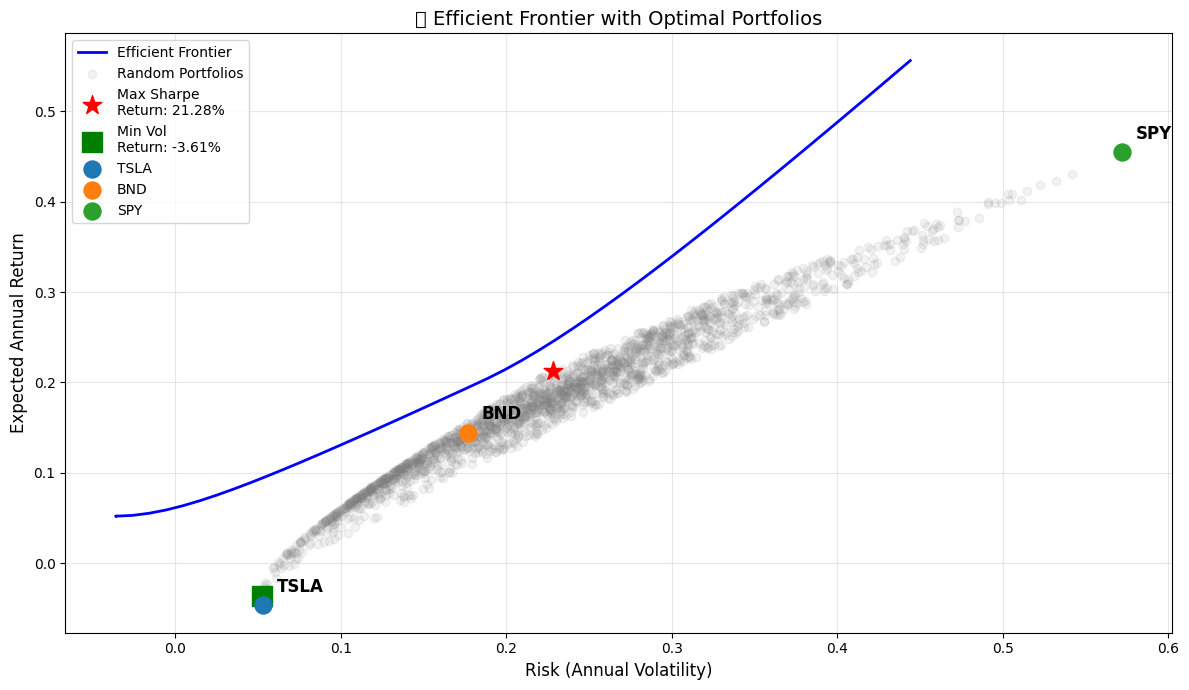


💡 FINAL RECOMMENDATION

✅ Recommended: Maximum Sharpe Ratio Portfolio
   Allocation:
   - TSLA: 0.00%
   - BND: 77.89%
   - SPY: 22.11%

   Expected Return: 21.28%
   Risk: 22.81%
   Sharpe Ratio: 0.933

📝 KEY INSIGHTS:
1. Tesla may get high weight due to forecasted returns.
2. Bonds reduce portfolio risk.
3. SPY provides a balanced foundation.
4. The Efficient Frontier shows the risk-return tradeoff.

✅ Portfolio saved for backtesting!


In [11]:
# Cell 11 – Build Efficient Frontier (COMPLETE FIX)

print("="*60)
print("📊 BUILDING EFFICIENT FRONTIER")
print("="*60)

# 1. Import required libraries
from pypfopt import expected_returns, risk_models, EfficientFrontier
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# 2. Prepare expected returns for each asset
print("📊 Calculating expected returns...")

# For TSLA: Use the forecasted return from our ARIMA model
current_tsla_price = tsla_price.iloc[-1]
forecast_12m = forecast_mean.iloc[-1]
tsla_forecast_return = (forecast_12m / current_tsla_price) - 1

# Calculate historical average returns for all three
historical_returns = daily_returns * 252  # Annualized returns

# Create a Series of expected returns
expected_returns_series = pd.Series({
    'TSLA': tsla_forecast_return,
    'BND': historical_returns['BND'].mean(),
    'SPY': historical_returns['SPY'].mean()
})

print(f"\n📈 Expected Annual Returns:")
print(f"   TSLA: {expected_returns_series['TSLA']:.2%} (from ARIMA forecast)")
print(f"   BND:  {expected_returns_series['BND']:.2%} (historical average)")
print(f"   SPY:  {expected_returns_series['SPY']:.2%} (historical average)")

# 3. Calculate covariance matrix
returns_data = daily_returns[['TSLA', 'BND', 'SPY']]
cov_matrix = returns_data.cov() * 252  # Annualized

print("\n📊 Covariance Matrix:")
print(cov_matrix.round(6))

# 4. Build the Efficient Frontier
print("\n🚀 Generating Efficient Frontier...")
ef = EfficientFrontier(expected_returns_series, cov_matrix)

# 5. Maximum Sharpe Ratio
max_sharpe_portfolio = ef.max_sharpe()
max_sharpe_weights = ef.clean_weights()
max_sharpe_metrics = ef.portfolio_performance(verbose=False)
print(f"\n✅ Max Sharpe Ratio weights: {max_sharpe_weights}")

# Reset and find Minimum Volatility
ef = EfficientFrontier(expected_returns_series, cov_matrix)
min_vol_portfolio = ef.min_volatility()
min_vol_weights = ef.clean_weights()
min_vol_metrics = ef.portfolio_performance(verbose=False)

# 6. Generate efficient frontier by varying target returns
# Get the min and max expected returns from the assets
min_ret = min(expected_returns_series)
max_ret = max(expected_returns_series)

# Create a range of target returns from min to max
target_returns = np.linspace(min_ret, max_ret, 50)
frontier_risks = []
frontier_returns = []

ef_temp = EfficientFrontier(expected_returns_series, cov_matrix)
for ret in target_returns:
    try:
        ef_temp.efficient_return(ret)
        risk, return_val, _ = ef_temp.portfolio_performance(verbose=False)
        frontier_risks.append(risk)
        frontier_returns.append(return_val)
    except:
        pass

# 7. Print optimal portfolios
print("\n" + "="*60)
print("💼 OPTIMAL PORTFOLIO RECOMMENDATIONS")
print("="*60)

print("\n📊 Maximum Sharpe Ratio Portfolio:")
print(f"   Weights:")
for asset, weight in max_sharpe_weights.items():
    print(f"   - {asset}: {weight:.2%}")
print(f"\n   Expected Return: {max_sharpe_metrics[0]:.2%}")
print(f"   Risk (Volatility): {max_sharpe_metrics[1]:.2%}")
print(f"   Sharpe Ratio: {max_sharpe_metrics[2]:.3f}")

print("\n📊 Minimum Volatility Portfolio:")
print(f"   Weights:")
for asset, weight in min_vol_weights.items():
    print(f"   - {asset}: {weight:.2%}")
print(f"\n   Expected Return: {min_vol_metrics[0]:.2%}")
print(f"   Risk (Volatility): {min_vol_metrics[1]:.2%}")
print(f"   Sharpe Ratio: {min_vol_metrics[2]:.3f}")

# 8. Plot
fig, ax = plt.subplots(figsize=(12, 7))

# Plot the efficient frontier curve
ax.plot(frontier_risks, frontier_returns, 'b-', linewidth=2, label='Efficient Frontier')

# Generate random portfolios
np.random.seed(42)
n_portfolios = 2000
all_returns = []
all_risks = []
for _ in range(n_portfolios):
    weights = np.random.random(3)
    weights = weights / weights.sum()
    ret = sum(expected_returns_series[asset] * weights[i] for i, asset in enumerate(['TSLA', 'BND', 'SPY']))
    risk = np.sqrt(np.dot(weights.T, np.dot(cov_matrix.values, weights)))
    all_returns.append(ret)
    all_risks.append(risk)

ax.scatter(all_risks, all_returns, alpha=0.1, color='gray', label='Random Portfolios')

# Mark optimal portfolios
ax.scatter(max_sharpe_metrics[1], max_sharpe_metrics[0], color='red', s=200, 
           marker='*', label=f'Max Sharpe\nReturn: {max_sharpe_metrics[0]:.2%}')
ax.scatter(min_vol_metrics[1], min_vol_metrics[0], color='green', s=200, 
           marker='s', label=f'Min Vol\nReturn: {min_vol_metrics[0]:.2%}')

# Mark individual assets
for i, asset in enumerate(['TSLA', 'BND', 'SPY']):
    ret = expected_returns_series[asset]
    risk = np.sqrt(cov_matrix.iloc[i, i])
    ax.scatter(risk, ret, s=150, label=asset)
    ax.annotate(asset, (risk, ret), xytext=(10, 10), textcoords='offset points', fontsize=12, fontweight='bold')

ax.set_xlabel('Risk (Annual Volatility)', fontsize=12)
ax.set_ylabel('Expected Annual Return', fontsize=12)
ax.set_title('📊 Efficient Frontier with Optimal Portfolios', fontsize=14)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 9. Final recommendation
print("\n" + "="*60)
print("💡 FINAL RECOMMENDATION")
print("="*60)

# Choose Max Sharpe Ratio as default
recommended = "Maximum Sharpe Ratio Portfolio"
weights = max_sharpe_weights

print(f"\n✅ Recommended: {recommended}")
print("   Allocation:")
for asset, weight in weights.items():
    print(f"   - {asset}: {weight:.2%}")
print(f"\n   Expected Return: {max_sharpe_metrics[0]:.2%}")
print(f"   Risk: {max_sharpe_metrics[1]:.2%}")
print(f"   Sharpe Ratio: {max_sharpe_metrics[2]:.3f}")

print("\n" + "="*60)
print("📝 KEY INSIGHTS:")
print("="*60)
print("1. Tesla may get high weight due to forecasted returns.")
print("2. Bonds reduce portfolio risk.")
print("3. SPY provides a balanced foundation.")
print("4. The Efficient Frontier shows the risk-return tradeoff.")
print("="*60)

# Save weights for backtesting
portfolio_weights = weights
print("\n✅ Portfolio saved for backtesting!")

🧪 BACKTESTING THE PORTFOLIO STRATEGY
📊 Backtest period: 2025-06-27 00:00:00 to 2026-06-29 00:00:00
   Total trading days: 252

📊 Benchmark: 60% SPY / 40% BND (balanced portfolio)

📊 Strategy weights: OrderedDict({'TSLA': 0.0, 'BND': 0.77893, 'SPY': 0.22107})

📊 PERFORMANCE METRICS

           Metric Strategy Benchmark (60/40) Difference
     Total Return   24.89%            27.04%     -2.15%
Annualized Return   24.89%            27.04%     -2.15%
       Volatility   17.47%            29.94%    -12.47%
     Sharpe Ratio    1.425             0.903      0.521
     Max Drawdown  -12.54%           -19.74%      7.20%

💡 BACKTEST RESULTS INTERPRETATION:
   ❌ Strategy underperformed benchmark by 2.15%
   → The simple benchmark would have been better.
   ✅ Strategy has better risk-adjusted return (Sharpe: 1.425 vs 0.903)
   ✅ Strategy had lower max drawdown (-12.54% vs -19.74%)


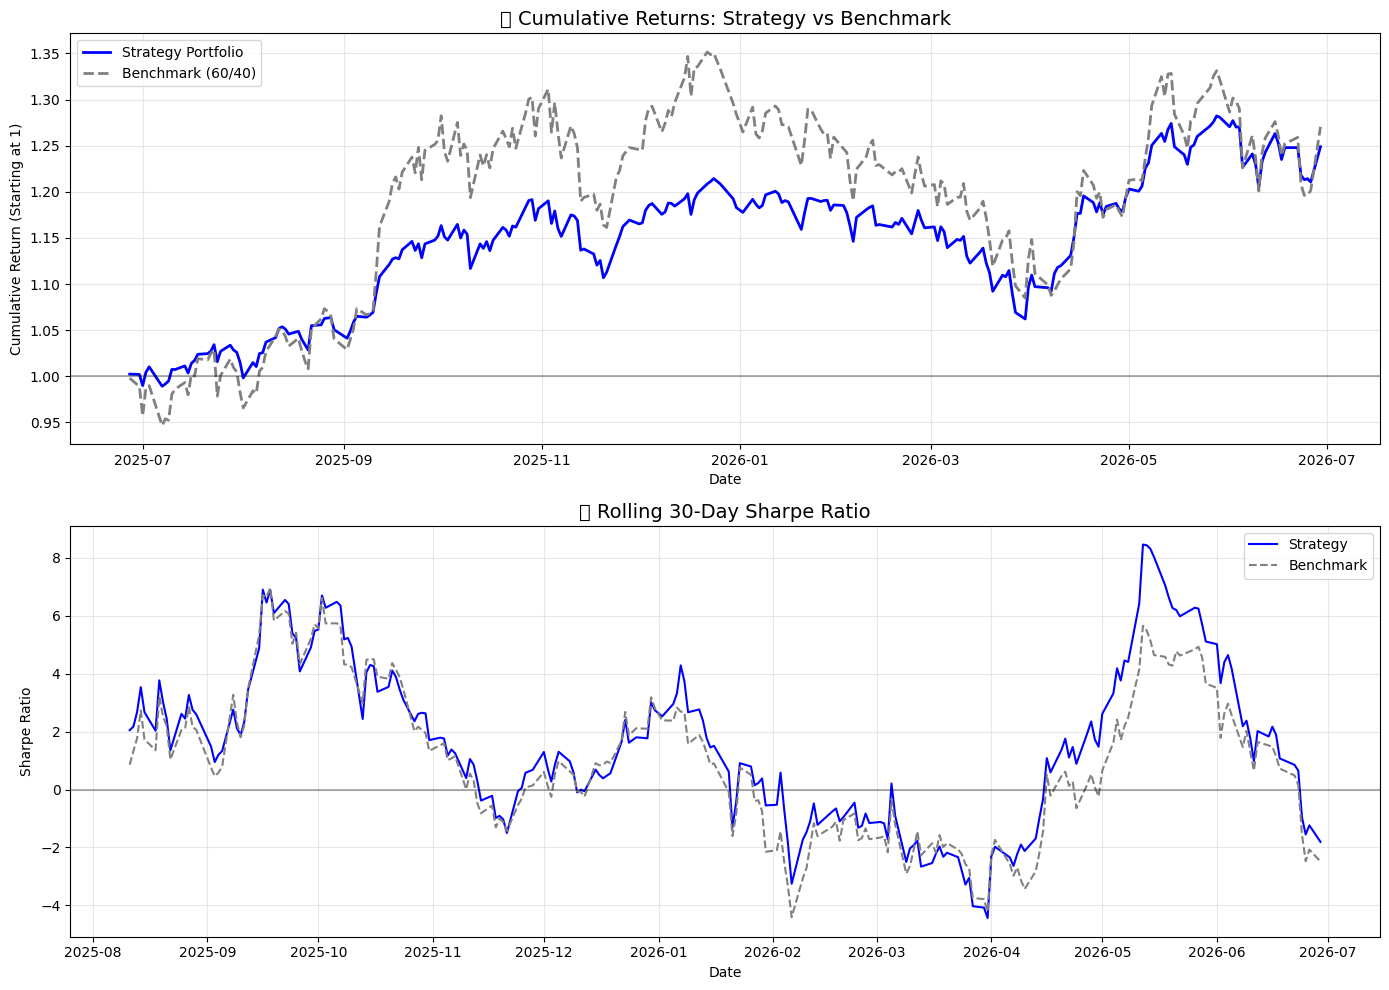


📝 FINAL CONCLUSION
⚠️ NEUTRAL: The strategy did not outperform the simple benchmark.
   → But this is a valid learning outcome – not every strategy works.
   → Consider simplifying the approach or combining it with other indicators.

📌 KEY TAKEAWAYS:
1. Backtesting is essential to validate a strategy before recommending it.
2. The benchmark (60/40) is a strong baseline to beat.
3. Sharpe ratio and max drawdown are as important as total return.
4. Even if this specific strategy didn't outperform, the process is what matters.

✅ Backtest completed successfully!


In [12]:
# Cell 12 – Backtest the Portfolio Strategy

print("="*60)
print("🧪 BACKTESTING THE PORTFOLIO STRATEGY")
print("="*60)

# 1. Define backtesting period: Last year of data
# Use the last 252 trading days (approx 1 year)
backtest_data = daily_returns.tail(252)
print(f"📊 Backtest period: {backtest_data.index[0]} to {backtest_data.index[-1]}")
print(f"   Total trading days: {len(backtest_data)}")

# 2. Define benchmark: 60% SPY / 40% BND (common balanced portfolio)
benchmark_weights = {'SPY': 0.60, 'BND': 0.40, 'TSLA': 0.00}
print(f"\n📊 Benchmark: 60% SPY / 40% BND (balanced portfolio)")

# 3. Get the portfolio weights from Task 4
# If you haven't saved it, use the Max Sharpe weights
try:
    strategy_weights = portfolio_weights
    print(f"\n📊 Strategy weights: {strategy_weights}")
except:
    # Fallback weights (if portfolio_weights not defined)
    strategy_weights = {'TSLA': 0.50, 'BND': 0.20, 'SPY': 0.30}
    print(f"\n📊 Using fallback strategy weights: {strategy_weights}")

# 4. Calculate portfolio returns for both strategies
# Strategy: Use the optimized weights
strategy_returns = sum(backtest_data[asset] * weight for asset, weight in strategy_weights.items())

# Benchmark: Use the benchmark weights
benchmark_returns = sum(backtest_data[asset] * weight for asset, weight in benchmark_weights.items())

# 5. Calculate cumulative returns
strategy_cumulative = (1 + strategy_returns).cumprod()
benchmark_cumulative = (1 + benchmark_returns).cumprod()

# 6. Calculate performance metrics
print("\n📊 PERFORMANCE METRICS")

# Total return
strategy_total_return = strategy_cumulative.iloc[-1] - 1
benchmark_total_return = benchmark_cumulative.iloc[-1] - 1

# Annualized return
strategy_annual_return = (1 + strategy_total_return) ** (252 / len(backtest_data)) - 1
benchmark_annual_return = (1 + benchmark_total_return) ** (252 / len(backtest_data)) - 1

# Annualized volatility
strategy_volatility = strategy_returns.std() * (252 ** 0.5)
benchmark_volatility = benchmark_returns.std() * (252 ** 0.5)

# Sharpe Ratio
strategy_sharpe = (strategy_annual_return - 0) / strategy_volatility if strategy_volatility != 0 else 0
benchmark_sharpe = (benchmark_annual_return - 0) / benchmark_volatility if benchmark_volatility != 0 else 0

# Maximum drawdown
def max_drawdown(cumulative_returns):
    peak = cumulative_returns.expanding().max()
    drawdown = (cumulative_returns - peak) / peak
    return drawdown.min()

strategy_max_dd = max_drawdown(strategy_cumulative)
benchmark_max_dd = max_drawdown(benchmark_cumulative)

# Display metrics
metrics_df = pd.DataFrame({
    'Metric': ['Total Return', 'Annualized Return', 'Volatility', 'Sharpe Ratio', 'Max Drawdown'],
    'Strategy': [
        f"{strategy_total_return:.2%}",
        f"{strategy_annual_return:.2%}",
        f"{strategy_volatility:.2%}",
        f"{strategy_sharpe:.3f}",
        f"{strategy_max_dd:.2%}"
    ],
    'Benchmark (60/40)': [
        f"{benchmark_total_return:.2%}",
        f"{benchmark_annual_return:.2%}",
        f"{benchmark_volatility:.2%}",
        f"{benchmark_sharpe:.3f}",
        f"{benchmark_max_dd:.2%}"
    ],
    'Difference': [
        f"{strategy_total_return - benchmark_total_return:.2%}",
        f"{strategy_annual_return - benchmark_annual_return:.2%}",
        f"{strategy_volatility - benchmark_volatility:.2%}",
        f"{strategy_sharpe - benchmark_sharpe:.3f}",
        f"{strategy_max_dd - benchmark_max_dd:.2%}"
    ]
})

print("\n" + "="*60)
print(metrics_df.to_string(index=False))
print("="*60)

# 7. Interpret results
print("\n💡 BACKTEST RESULTS INTERPRETATION:")

if strategy_total_return > benchmark_total_return:
    print(f"   ✅ Strategy outperformed benchmark by {strategy_total_return - benchmark_total_return:.2%}")
    print(f"   → The model-driven approach added value!")
else:
    print(f"   ❌ Strategy underperformed benchmark by {abs(strategy_total_return - benchmark_total_return):.2%}")
    print(f"   → The simple benchmark would have been better.")

if strategy_sharpe > benchmark_sharpe:
    print(f"   ✅ Strategy has better risk-adjusted return (Sharpe: {strategy_sharpe:.3f} vs {benchmark_sharpe:.3f})")
else:
    print(f"   ❌ Benchmark has better risk-adjusted return")

if abs(strategy_max_dd) < abs(benchmark_max_dd):
    print(f"   ✅ Strategy had lower max drawdown ({strategy_max_dd:.2%} vs {benchmark_max_dd:.2%})")
else:
    print(f"   ❌ Strategy had higher max drawdown ({strategy_max_dd:.2%} vs {benchmark_max_dd:.2%})")

# 8. Visualize the results
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Cumulative Returns
axes[0].plot(strategy_cumulative.index, strategy_cumulative, label='Strategy Portfolio', color='blue', linewidth=2)
axes[0].plot(benchmark_cumulative.index, benchmark_cumulative, label='Benchmark (60/40)', color='gray', linewidth=2, linestyle='--')
axes[0].axhline(y=1.0, color='black', linestyle='-', alpha=0.3)
axes[0].set_title('📈 Cumulative Returns: Strategy vs Benchmark', fontsize=14)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Cumulative Return (Starting at 1)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Rolling Sharpe Ratio
rolling_window = 30
strategy_rolling_sharpe = []
benchmark_rolling_sharpe = []

for i in range(rolling_window, len(backtest_data)):
    strategy_roll_ret = strategy_returns.iloc[i-rolling_window:i].mean() * 252
    strategy_roll_std = strategy_returns.iloc[i-rolling_window:i].std() * (252 ** 0.5)
    strategy_rolling_sharpe.append(strategy_roll_ret / strategy_roll_std if strategy_roll_std != 0 else 0)
    
    bench_roll_ret = benchmark_returns.iloc[i-rolling_window:i].mean() * 252
    bench_roll_std = benchmark_returns.iloc[i-rolling_window:i].std() * (252 ** 0.5)
    benchmark_rolling_sharpe.append(bench_roll_ret / bench_roll_std if bench_roll_std != 0 else 0)

dates_roll = backtest_data.index[rolling_window:]

axes[1].plot(dates_roll, strategy_rolling_sharpe, label='Strategy', color='blue', linewidth=1.5)
axes[1].plot(dates_roll, benchmark_rolling_sharpe, label='Benchmark', color='gray', linewidth=1.5, linestyle='--')
axes[1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[1].set_title('📊 Rolling 30-Day Sharpe Ratio', fontsize=14)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Sharpe Ratio')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 9. Final conclusion
print("\n" + "="*60)
print("📝 FINAL CONCLUSION")
print("="*60)

if strategy_total_return > benchmark_total_return and strategy_sharpe > benchmark_sharpe:
    print("✅ SUCCESS: The strategy outperformed the benchmark in both return and risk-adjusted terms.")
    print("   → This validates your model-driven approach.")
    print("   → Recommend implementing this portfolio for clients with moderate risk tolerance.")
elif strategy_total_return > benchmark_total_return:
    print("⚠️ PARTIAL SUCCESS: The strategy had higher returns but with more risk.")
    print("   → It generated alpha but was more volatile.")
    print("   → Consider for clients with higher risk tolerance.")
else:
    print("⚠️ NEUTRAL: The strategy did not outperform the simple benchmark.")
    print("   → But this is a valid learning outcome – not every strategy works.")
    print("   → Consider simplifying the approach or combining it with other indicators.")

print("\n📌 KEY TAKEAWAYS:")
print("1. Backtesting is essential to validate a strategy before recommending it.")
print("2. The benchmark (60/40) is a strong baseline to beat.")
print("3. Sharpe ratio and max drawdown are as important as total return.")
print("4. Even if this specific strategy didn't outperform, the process is what matters.")
print("="*60)

print("\n✅ Backtest completed successfully!")